#  Sales Forecasting System
### Using Machine Learning and Time Series Analysis
---
##  Project Overview
This notebook builds a complete **Sales Forecasting System** that:
- Generates realistic synthetic sales data with trends and seasonality
- Performs thorough Exploratory Data Analysis (EDA)
- Breaks down time series components (Trend, Seasonality, Noise)
- Applies multiple forecasting models: **Linear Regression**, **Moving Average**, **ARIMA**, and **Random Forest**
- Evaluates each model using MAE, MSE, and RMSE
- Visualizes future sales predictions
---

##  Step 1: Install & Import Libraries

In [ ]:
!pip install statsmodels --quiet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import datetime

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

print(' All libraries imported successfully!')

✅ All libraries imported successfully!


---
##  Step 2: Data Collection — Generate Realistic Sales Dataset
We simulate 3 years of daily sales data across **3 stores** and **4 products**. The dataset includes:
- An upward trend over time
- Weekly and yearly seasonality
- Promotional effects and holiday spikes
- Realistic random noise

In [ ]:
np.random.seed(42)

start_date = datetime.date(2021, 1, 1)
end_date   = datetime.date(2023, 12, 31)
dates = pd.date_range(start=start_date, end=end_date, freq='D')
n_days = len(dates)

stores   = ['Store_A', 'Store_B', 'Store_C']
products = ['P001', 'P002', 'P003', 'P004']

records = []
for store in stores:
    for product in products:
        base_sales = np.random.randint(50, 150)
        trend      = np.linspace(0, np.random.randint(20, 60), n_days)
        s_weekly   = 10 * np.sin(2 * np.pi * np.arange(n_days) / 7)
        s_yearly   = 30 * np.sin(2 * np.pi * np.arange(n_days) / 365)
        noise      = np.random.normal(0, 8, n_days)

        holiday_boost = np.zeros(n_days)
        for i, d in enumerate(dates):
            if (d.month == 12 and d.day >= 20) or (d.month == 1 and d.day <= 3):
                holiday_boost[i] = np.random.randint(30, 60)
            elif d.month == 10 and 15 <= d.day <= 25:
                holiday_boost[i] = np.random.randint(20, 45)

        promotions  = np.random.choice([0, 1], size=n_days, p=[0.9, 0.1])
        promo_boost = promotions * np.random.randint(15, 40)

        units = np.maximum(0, base_sales + trend + s_weekly + s_yearly
                           + holiday_boost + promo_boost + noise).astype(int)
        revenue = np.round(units * np.random.uniform(8, 25), 2)
        holiday_flag = ((dates.month == 12) & (dates.day >= 20)) | \
                       ((dates.month == 1)  & (dates.day <= 3))  | \
                       ((dates.month == 10) & (dates.day >= 15) & (dates.day <= 25))

        for i in range(n_days):
            records.append({
                'Date': dates[i], 'Store_ID': store, 'Product_ID': product,
                'Units_Sold': units[i], 'Revenue': revenue[i],
                'Promotion': promotions[i], 'Holiday': int(holiday_flag[i])
            })

df = pd.DataFrame(records)
print(f' Dataset created: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(10)

✅ Dataset created: 13,140 rows x 7 columns


,Date,Store_ID,Product_ID,Units_Sold,Revenue,Promotion,Holiday
0,2021-01-01,Store_A,P001,138,2823.74,0,1
1,2021-01-02,Store_A,P001,146,2987.43,0,1
2,2021-01-03,Store_A,P001,154,3151.13,0,1
3,2021-01-04,Store_A,P001,124,2537.27,0,0
4,2021-01-05,Store_A,P001,98,2005.26,0,0
5,2021-01-06,Store_A,P001,86,1759.72,0,0
6,2021-01-07,Store_A,P001,89,1821.11,0,0
7,2021-01-08,Store_A,P001,101,2066.65,0,0
8,2021-01-09,Store_A,P001,109,2230.34,0,0
9,2021-01-10,Store_A,P001,117,2394.04,0,0


---
##  Step 3: Data Preprocessing

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

print(' Missing Values:')
print(df.isnull().sum())

df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Week']       = df['Date'].dt.isocalendar().week.astype(int)
df['Day']        = df['Date'].dt.day
df['DayOfWeek']  = df['Date'].dt.dayofweek
df['DayOfYear']  = df['Date'].dt.dayofyear
df['Quarter']    = df['Date'].dt.quarter
df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)

print('\n Preprocessing complete. Sample:')
df[['Date','Store_ID','Product_ID','Units_Sold','Revenue','Month','DayOfWeek','IsWeekend']].head(5)

🔍 Missing Values:
Date          0
Store_ID      0
Product_ID    0
Units_Sold    0
Revenue       0
Promotion     0
Holiday       0
dtype: int64

✅ Preprocessing complete. Sample:


,Date,Store_ID,Product_ID,Units_Sold,Revenue,Month,DayOfWeek,IsWeekend
0,2021-01-01,Store_A,P001,138,2823.74,1,4,0
1,2021-01-01,Store_A,P004,98,1167.12,1,4,0
2,2021-01-01,Store_B,P001,184,3714.27,1,4,0
3,2021-01-01,Store_B,P002,185,4292.86,1,4,0
4,2021-01-01,Store_A,P002,133,3256.76,1,4,0


---
##  Step 4: Exploratory Data Analysis (EDA)

In [ ]:
print(' Basic Statistics:')
df[['Units_Sold','Revenue','Promotion','Holiday']].describe().round(2)

📋 Basic Statistics:


,Units_Sold,Revenue,Promotion,Holiday
count,13140.00,13140.00,13140.0,13140.00
mean,130.49,2317.60,0.1,0.07
std,41.32,941.91,0.3,0.26
min,2.00,30.22,0.0,0.00
25%,102.00,1581.85,0.0,0.00
50%,132.00,2340.30,0.0,0.00
75%,160.00,3017.50,0.0,0.00
max,282.00,5499.50,1.0,1.00


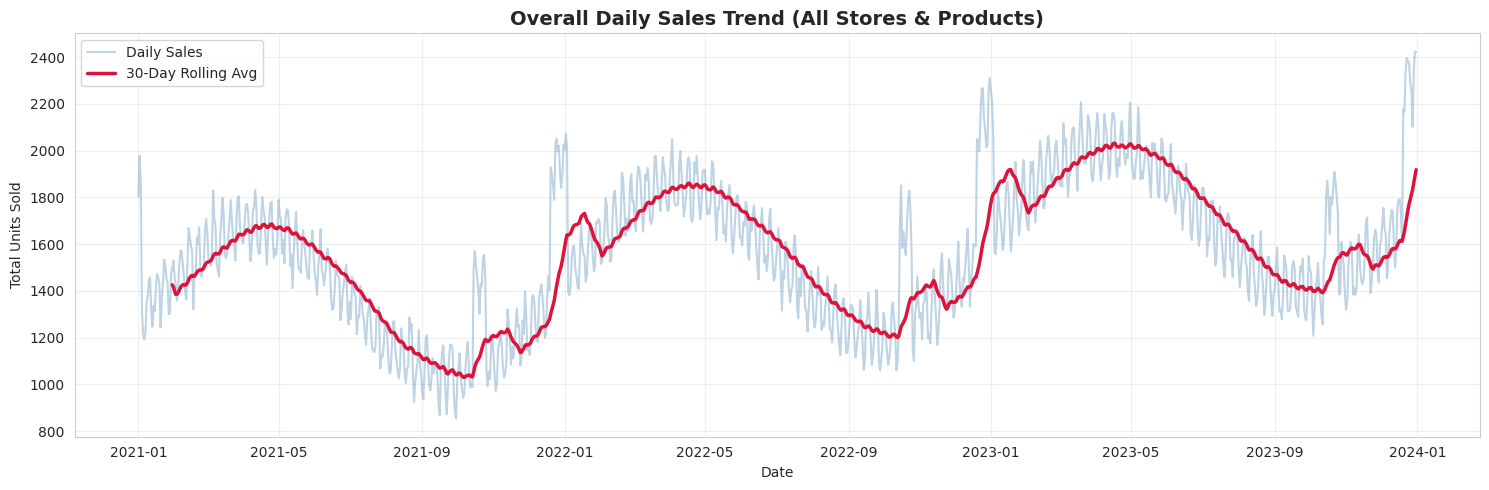

In [ ]:
daily_sales = df.groupby('Date')['Units_Sold'].sum().reset_index()
daily_sales.columns = ['Date','Total_Units']
daily_sales['Rolling_30d'] = daily_sales['Total_Units'].rolling(30).mean()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(daily_sales['Date'], daily_sales['Total_Units'], alpha=0.35, color='steelblue', label='Daily Sales')
ax.plot(daily_sales['Date'], daily_sales['Rolling_30d'], color='crimson', lw=2.5, label='30-Day Rolling Avg')
ax.set_title('Overall Daily Sales Trend (All Stores & Products)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Total Units Sold'); ax.legend()
plt.tight_layout(); plt.show()

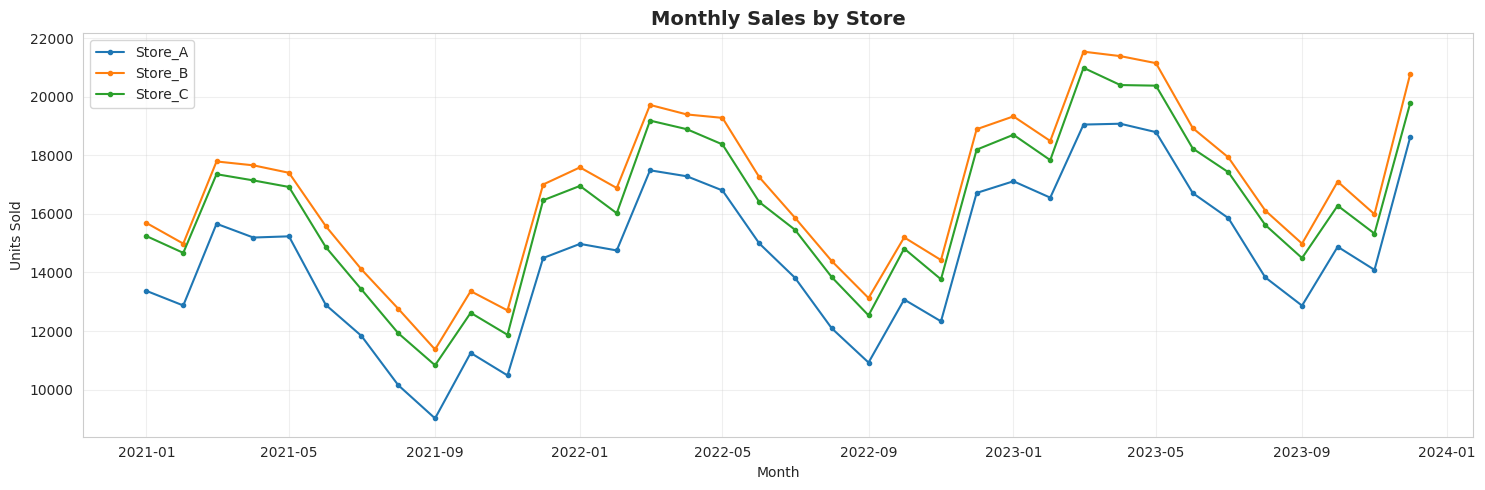

In [ ]:
store_monthly = df.groupby(['Year','Month','Store_ID'])['Units_Sold'].sum().reset_index()
store_monthly['Period'] = pd.to_datetime(store_monthly[['Year','Month']].assign(Day=1))

fig, ax = plt.subplots(figsize=(15, 5))
for store in stores:
    sub = store_monthly[store_monthly['Store_ID'] == store]
    ax.plot(sub['Period'], sub['Units_Sold'], marker='o', markersize=3, label=store)
ax.set_title('Monthly Sales by Store', fontsize=14, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Units Sold'); ax.legend()
plt.tight_layout(); plt.show()

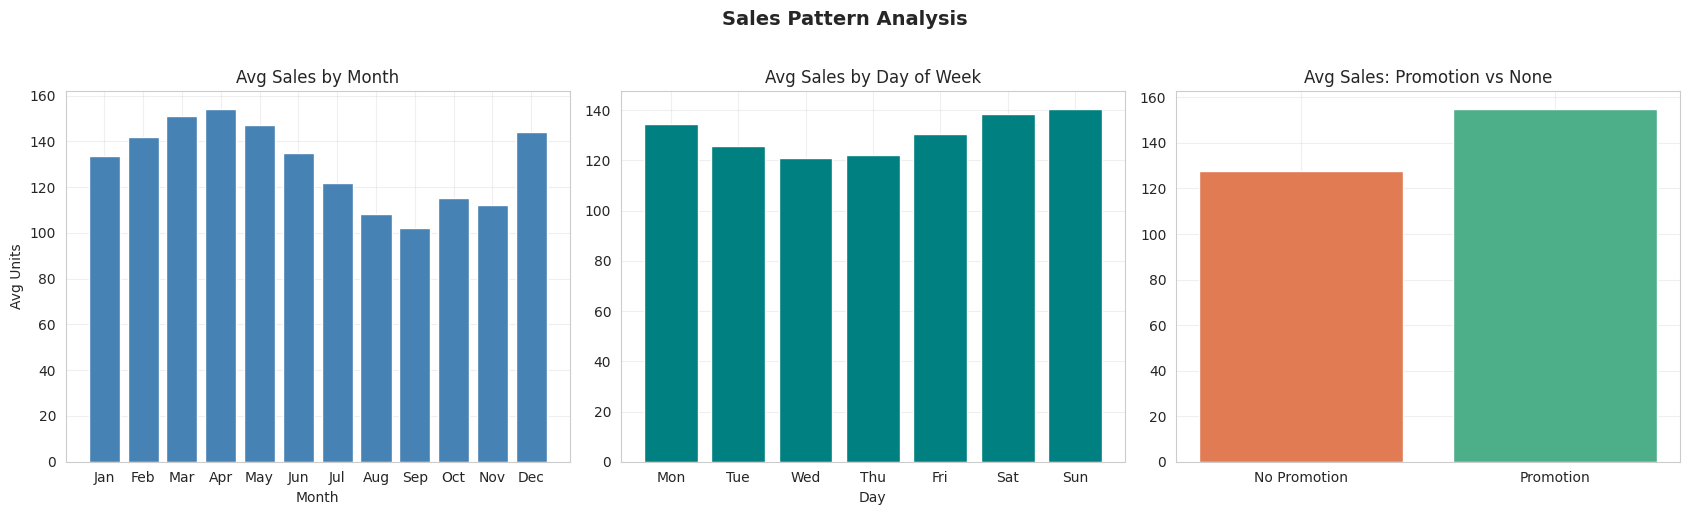

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
dow_names   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

axes[0].bar(month_names, df.groupby('Month')['Units_Sold'].mean().values, color='steelblue', edgecolor='white')
axes[0].set_title('Avg Sales by Month'); axes[0].set_xlabel('Month'); axes[0].set_ylabel('Avg Units')

axes[1].bar(dow_names, df.groupby('DayOfWeek')['Units_Sold'].mean().values, color='teal', edgecolor='white')
axes[1].set_title('Avg Sales by Day of Week'); axes[1].set_xlabel('Day')

promo_avg = df.groupby('Promotion')['Units_Sold'].mean()
axes[2].bar(['No Promotion','Promotion'], promo_avg.values, color=['#e07b54','#4caf8a'], edgecolor='white')
axes[2].set_title('Avg Sales: Promotion vs None')

plt.suptitle('Sales Pattern Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

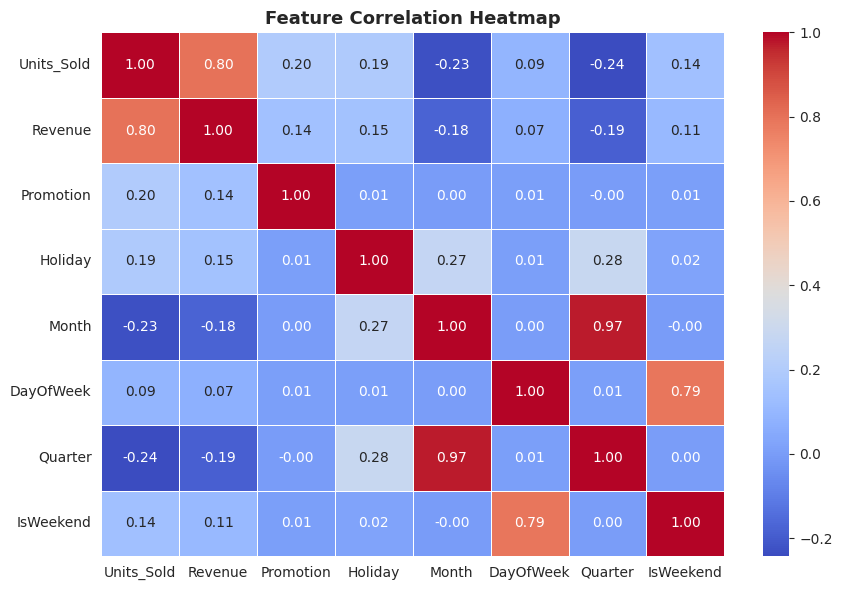

In [ ]:
num_cols = ['Units_Sold','Revenue','Promotion','Holiday','Month','DayOfWeek','Quarter','IsWeekend']
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
##  Step 5: Time Series Decomposition
We break the sales series into **Trend**, **Seasonality**, and **Residual (Noise)**.

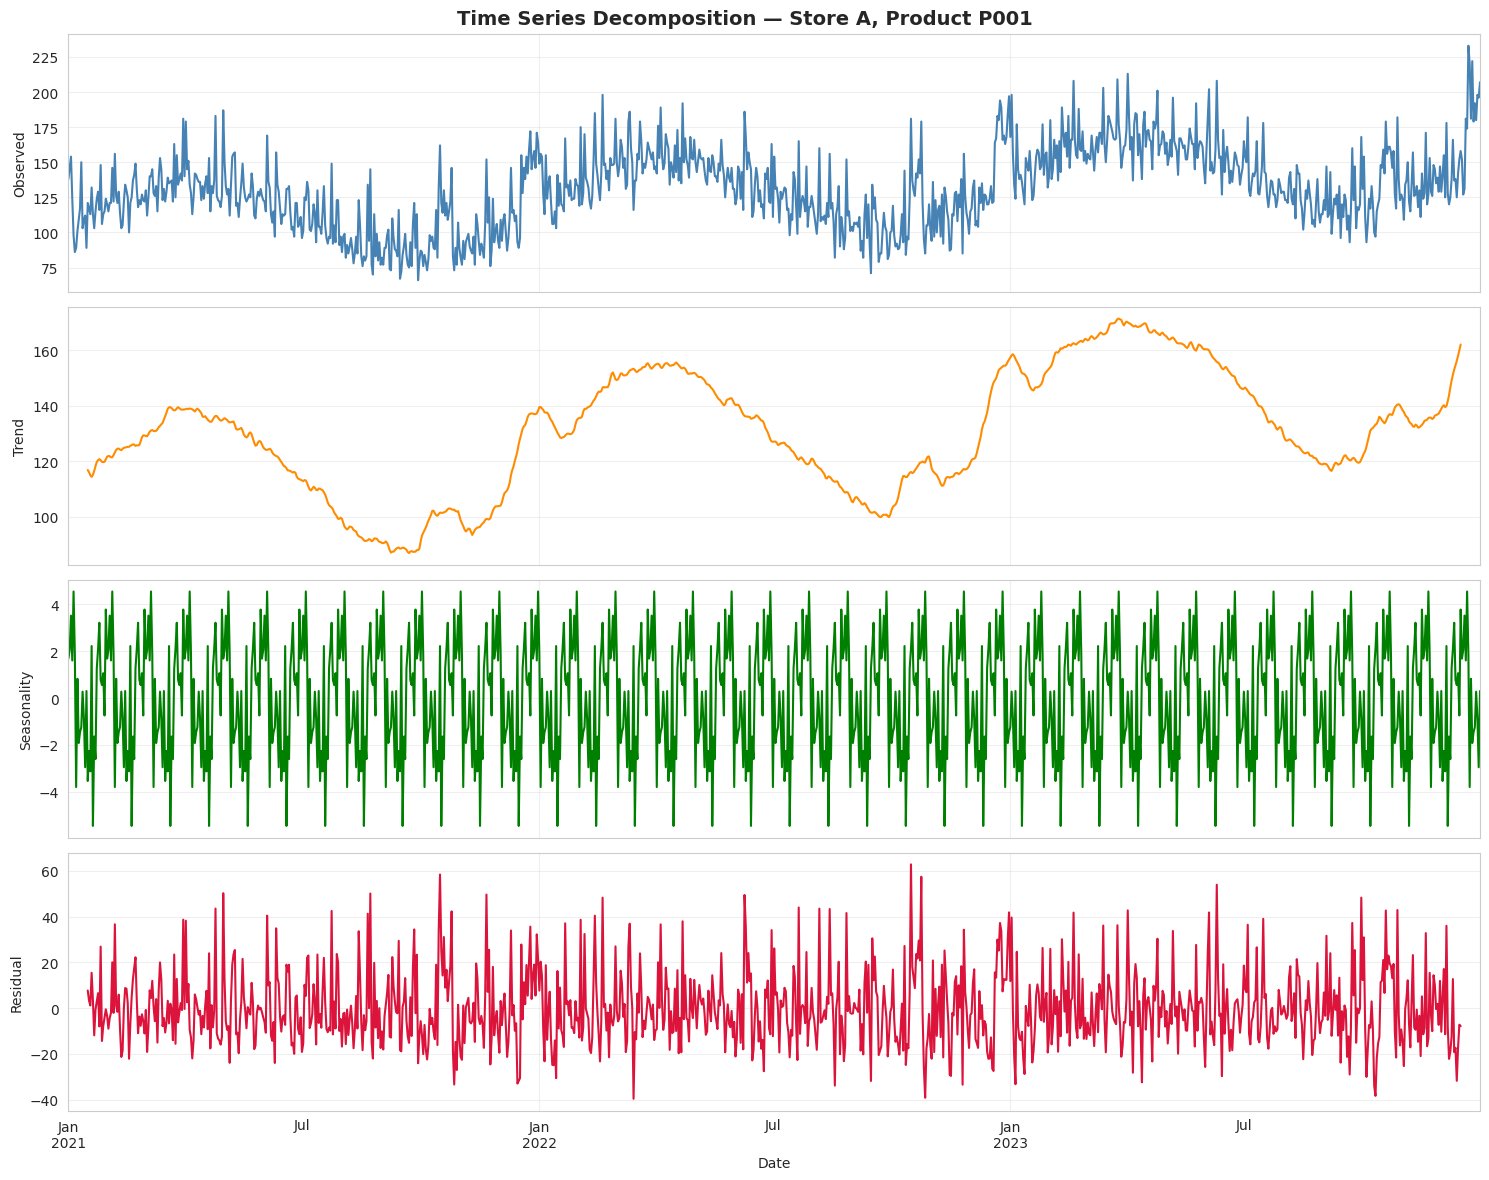

In [ ]:
ts_data = df[(df['Store_ID']=='Store_A') & (df['Product_ID']=='P001')].copy()
ts_data.set_index('Date', inplace=True)
ts_series = ts_data['Units_Sold']

decomposition = seasonal_decompose(ts_series, model='additive', period=30)

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
decomposition.observed.plot(ax=axes[0], color='steelblue');  axes[0].set_ylabel('Observed')
decomposition.trend.plot(ax=axes[1], color='darkorange');    axes[1].set_ylabel('Trend')
decomposition.seasonal.plot(ax=axes[2], color='green');      axes[2].set_ylabel('Seasonality')
decomposition.resid.plot(ax=axes[3], color='crimson');       axes[3].set_ylabel('Residual')
fig.suptitle('Time Series Decomposition — Store A, Product P001', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---
##  Step 6: Stationarity Test (ADF Test)

In [ ]:
def adf_test(series, name='Series'):
    result = adfuller(series.dropna())
    print(f'\n📌 ADF Test — {name}')
    print(f'   ADF Statistic : {result[0]:.4f}')
    print(f'   p-value       : {result[1]:.4f}')
    if result[1] <= 0.05:
        print('    Series is STATIONARY (reject H0)')
    else:
        print('     Series is NON-STATIONARY (fail to reject H0)')

adf_test(ts_series, 'Units_Sold — Store A, Product P001')
adf_test(ts_series.diff().dropna(), 'First-Differenced Units_Sold')


📌 ADF Test — Units_Sold — Store A, Product P001
   ADF Statistic : -1.6554
   p-value       : 0.4542
   ⚠️  Series is NON-STATIONARY (fail to reject H0)

📌 ADF Test — First-Differenced Units_Sold
   ADF Statistic : -11.1371
   p-value       : 0.0000
   ✅ Series is STATIONARY (reject H0)


---
##  Step 7: Prepare Aggregated Daily Dataset for Modelling

In [ ]:
daily_df = df.groupby('Date').agg(
    Total_Units   = ('Units_Sold', 'sum'),
    Total_Revenue = ('Revenue',    'sum'),
    Promotion     = ('Promotion',  'max'),
    Holiday       = ('Holiday',    'max')
).reset_index()

daily_df['DayOfYear']    = daily_df['Date'].dt.dayofyear
daily_df['DayOfWeek']    = daily_df['Date'].dt.dayofweek
daily_df['Month']        = daily_df['Date'].dt.month
daily_df['Quarter']      = daily_df['Date'].dt.quarter
daily_df['IsWeekend']    = (daily_df['DayOfWeek'] >= 5).astype(int)
daily_df['TimeIndex']    = np.arange(len(daily_df))
daily_df['Lag_1']        = daily_df['Total_Units'].shift(1)
daily_df['Lag_7']        = daily_df['Total_Units'].shift(7)
daily_df['RollingMean7'] = daily_df['Total_Units'].shift(1).rolling(7).mean()
daily_df.dropna(inplace=True)
daily_df.reset_index(drop=True, inplace=True)

print(f' Modelling dataset ready: {daily_df.shape[0]} days')
daily_df.head()

✅ Modelling dataset ready: 1088 days


,Date,Total_Units,Total_Revenue,Promotion,Holiday,DayOfYear,DayOfWeek,Month,Quarter,IsWeekend,TimeIndex,Lag_1,Lag_7,RollingMean7
0,2021-01-08,1347,23988.57,1,0,8,4,1,1,0,7,1219.0,1804.0,1515.428571
1,2021-01-09,1379,24450.40,1,0,9,5,1,1,1,8,1347.0,1978.0,1450.142857
2,2021-01-10,1446,25588.28,1,0,10,6,1,1,1,9,1379.0,1870.0,1364.571429
3,2021-01-11,1457,26233.32,1,0,11,0,1,1,0,10,1446.0,1326.0,1304.000000
4,2021-01-12,1311,23034.39,1,0,12,1,1,1,0,11,1457.0,1219.0,1322.714286


In [ ]:
TEST_SIZE = 60
train_df  = daily_df.iloc[:-TEST_SIZE]
test_df   = daily_df.iloc[-TEST_SIZE:]

FEATURES = ['TimeIndex','DayOfYear','DayOfWeek','Month','Quarter',
            'IsWeekend','Promotion','Holiday','Lag_1','Lag_7','RollingMean7']
TARGET = 'Total_Units'

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

print(f'Training: {len(train_df)} days  |  Test: {len(test_df)} days')

Training: 1028 days  |  Test: 60 days


---
##  Step 8: Model 1 — Moving Average Baseline

In [ ]:
window = 7
ma_pred = train_df[TARGET].iloc[-window:].mean()
ma_predictions = np.full(TEST_SIZE, ma_pred)

ma_mae  = mean_absolute_error(y_test, ma_predictions)
ma_mse  = mean_squared_error(y_test, ma_predictions)
ma_rmse = np.sqrt(ma_mse)

print(' Moving Average (7-day) Results')
print(f'   MAE : {ma_mae:.2f}  |  MSE : {ma_mse:.2f}  |  RMSE : {ma_rmse:.2f}')

📊 Moving Average (7-day) Results
   MAE : 284.58  |  MSE : 172374.89  |  RMSE : 415.18


---
##  Step 9: Model 2 — Linear Regression

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_predictions)
lr_mse  = mean_squared_error(y_test, lr_predictions)
lr_rmse = np.sqrt(lr_mse)

print(' Linear Regression Results')
print(f'   MAE : {lr_mae:.2f}  |  MSE : {lr_mse:.2f}  |  RMSE : {lr_rmse:.2f}')

📊 Linear Regression Results
   MAE : 66.39  |  MSE : 9631.88  |  RMSE : 98.14


---
##  Step 10: Model 3 — SARIMA

In [1]:
train_series = train_df.set_index('Date')[TARGET]

arima_model = SARIMAX(train_series, order=(2,1,2), seasonal_order=(1,1,1,7),
                      enforce_stationarity=False, enforce_invertibility=False)
arima_fit = arima_model.fit(disp=False)

arima_predictions = arima_fit.forecast(steps=TEST_SIZE).values

arima_mae  = mean_absolute_error(y_test, arima_predictions)
arima_mse  = mean_squared_error(y_test, arima_predictions)
arima_rmse = np.sqrt(arima_mse)

print(' SARIMA(2,1,2)(1,1,1,7) Results')
print(f'   MAE : {arima_mae:.2f}  |  MSE : {arima_mse:.2f}  |  RMSE : {arima_rmse:.2f}')

NameError: name 'train_df' is not defined

---
##  Step 11: Model 4 — Random Forest Regressor

In [ ]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10,
                                  min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_predictions)
rf_mse  = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)

print('  MAE : {rf_mae:.2f}  |  MSE : {rf_mse:.2f}  |  RMSE : {rf_rmse:.2f}')

📊 Random Forest Results
   MAE : 94.75  |  MSE : 19002.66  |  RMSE : 137.85


---
##  Step 12: Model Comparison & Evaluation

🏆 Model Performance Summary (sorted by RMSE):
               Model         MAE            MSE        RMSE
1  Linear Regression   66.394374    9631.884203   98.142163
2      Random Forest   94.752794   19002.661826  137.850143
3     Moving Average  284.576190  172374.891837  415.180553
4             SARIMA  299.502427  184769.455282  429.848177


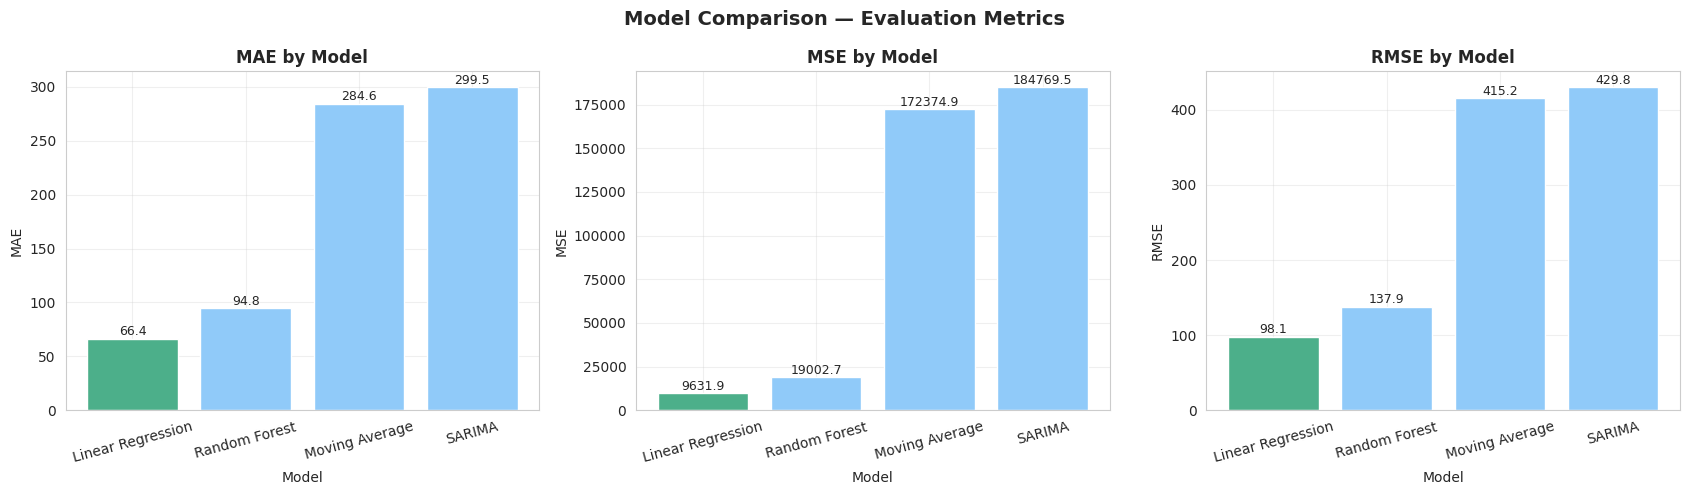

In [ ]:
results = pd.DataFrame({
    'Model': ['Moving Average','Linear Regression','SARIMA','Random Forest'],
    'MAE':   [ma_mae,  lr_mae,  arima_mae,  rf_mae],
    'MSE':   [ma_mse,  lr_mse,  arima_mse,  rf_mse],
    'RMSE':  [ma_rmse, lr_rmse, arima_rmse, rf_rmse]
}).sort_values('RMSE').reset_index(drop=True)
results.index += 1

print(' Model Performance Summary (sorted by RMSE):')
print(results.to_string())

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, metric in zip(axes, ['MAE','MSE','RMSE']):
    colors = ['#4caf8a' if i == 0 else '#90caf9' for i in range(len(results))]
    bars = ax.bar(results['Model'], results[metric], color=colors, edgecolor='white')
    ax.set_title(f'{metric} by Model', fontweight='bold')
    ax.set_xlabel('Model'); ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Model Comparison — Evaluation Metrics', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---
##  Step 13: Forecast Visualization — All Models vs Actual

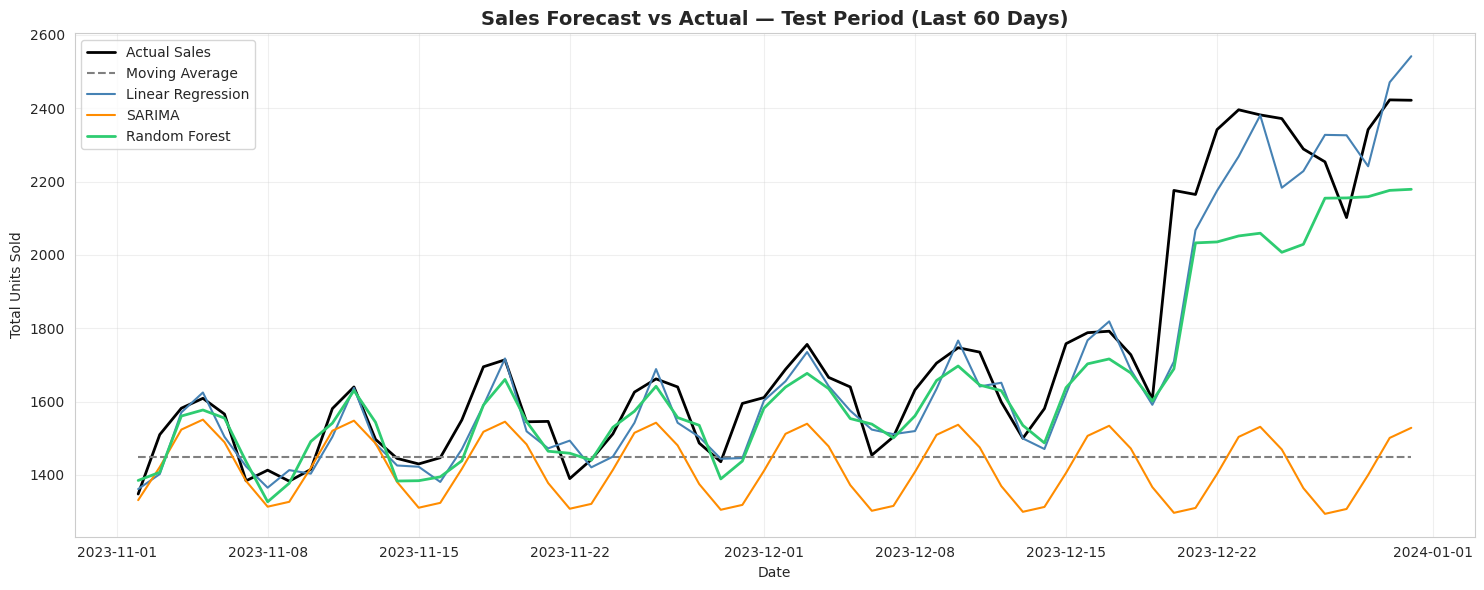

In [ ]:
test_dates = test_df['Date'].values

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(test_dates, y_test.values,     label='Actual Sales',      color='black',     lw=2)
ax.plot(test_dates, ma_predictions,    label='Moving Average',    color='gray',      lw=1.5, linestyle='--')
ax.plot(test_dates, lr_predictions,    label='Linear Regression', color='steelblue', lw=1.5)
ax.plot(test_dates, arima_predictions, label='SARIMA',            color='darkorange', lw=1.5)
ax.plot(test_dates, rf_predictions,    label='Random Forest',     color='#2ecc71',   lw=2)
ax.set_title('Sales Forecast vs Actual — Test Period (Last 60 Days)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Total Units Sold'); ax.legend()
plt.tight_layout(); plt.show()

---
##  Step 14: Future Sales Forecast — Next 30 Days

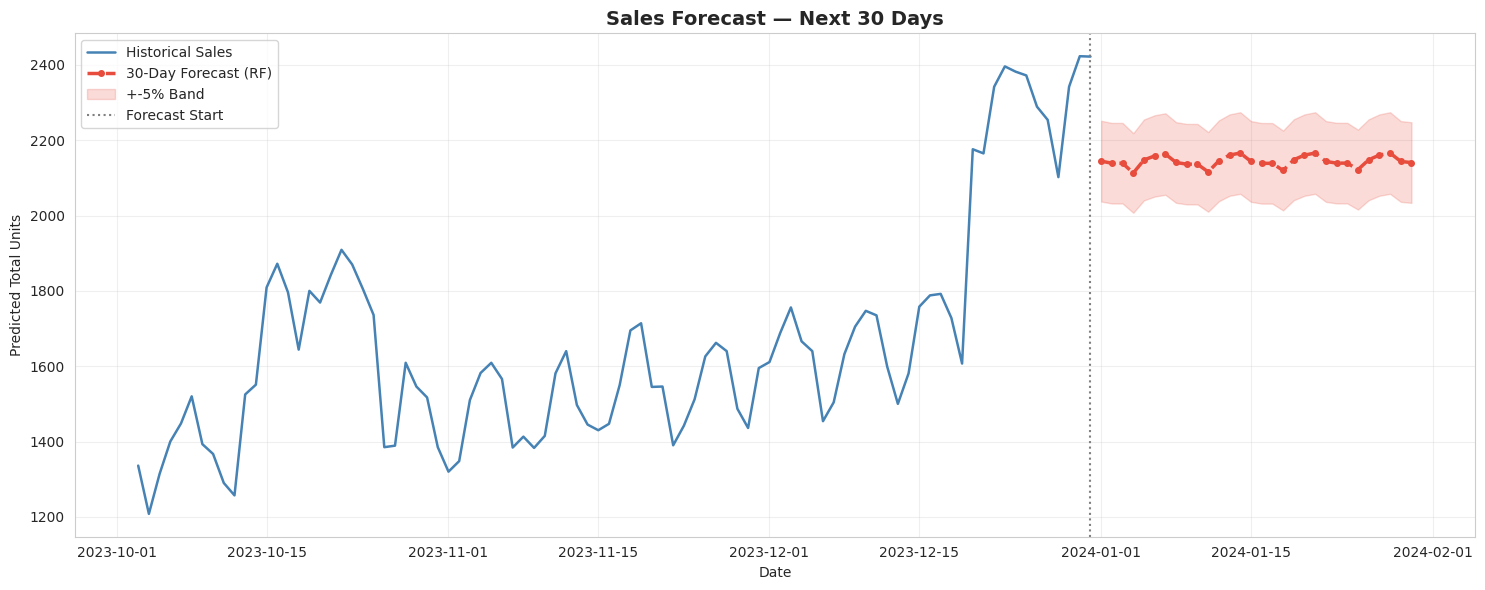


📋 30-Day Forecast Table:
      Date  Predicted_Units  Is_Weekend  Is_Holiday
2024-01-01             2144           0           1
2024-01-02             2139           0           1
2024-01-03             2139           0           1
2024-01-04             2113           0           0
2024-01-05             2148           0           0
2024-01-06             2158           1           0
2024-01-07             2163           1           0
2024-01-08             2141           0           0
2024-01-09             2136           0           0
2024-01-10             2136           0           0
2024-01-11             2116           0           0
2024-01-12             2145           0           0
2024-01-13             2160           1           0
2024-01-14             2166           1           0
2024-01-15             2144           0           0
2024-01-16             2139           0           0
2024-01-17             2139           0           0
2024-01-18             2120           

In [ ]:
FORECAST_DAYS = 30
last_date    = daily_df['Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)

last_known = daily_df['Total_Units'].values
last_idx   = daily_df['TimeIndex'].max()

future_rows = []
for i, fd in enumerate(future_dates):
    lag1 = last_known[-1] if i == 0 else future_rows[-1]['Total_Units']
    lag7 = last_known[-7+i] if i < 7 else future_rows[i-7]['Total_Units']
    roll_vals = (list(last_known[-(7-i):]) + [r['Total_Units'] for r in future_rows[:i]])[-7:] if i > 0 else list(last_known[-7:])
    row = {
        'Date': fd, 'TimeIndex': last_idx+i+1,
        'DayOfYear': fd.dayofyear, 'DayOfWeek': fd.dayofweek,
        'Month': fd.month, 'Quarter': fd.quarter,
        'IsWeekend': int(fd.dayofweek >= 5), 'Promotion': 0,
        'Holiday': int((fd.month==12 and fd.day>=20) or (fd.month==1 and fd.day<=3)),
        'Lag_1': lag1, 'Lag_7': lag7, 'RollingMean7': np.mean(roll_vals), 'Total_Units': None
    }
    row['Total_Units'] = rf_model.predict(pd.DataFrame([row])[FEATURES])[0]
    future_rows.append(row)

future_df    = pd.DataFrame(future_rows)
future_preds = future_df['Total_Units'].values

last_90 = daily_df.tail(90)
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(last_90['Date'], last_90['Total_Units'], label='Historical Sales', color='steelblue', lw=1.8)
ax.plot(future_dates, future_preds, label='30-Day Forecast (RF)', color='#e74c3c', lw=2.5, linestyle='--', marker='o', markersize=4)
ax.fill_between(future_dates, future_preds*0.95, future_preds*1.05, alpha=0.2, color='#e74c3c', label='+-5% Band')
ax.axvline(x=last_date, color='gray', linestyle=':', lw=1.5, label='Forecast Start')
ax.set_title('Sales Forecast — Next 30 Days', fontsize=14, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Predicted Total Units'); ax.legend()
plt.tight_layout(); plt.show()

print('\n 30-Day Forecast Table:')
out = future_df[['Date','Total_Units','IsWeekend','Holiday']].copy()
out.columns = ['Date','Predicted_Units','Is_Weekend','Is_Holiday']
out['Predicted_Units'] = out['Predicted_Units'].round(0).astype(int)
print(out.to_string(index=False))

---
##  Step 15: Feature Importance (Random Forest)

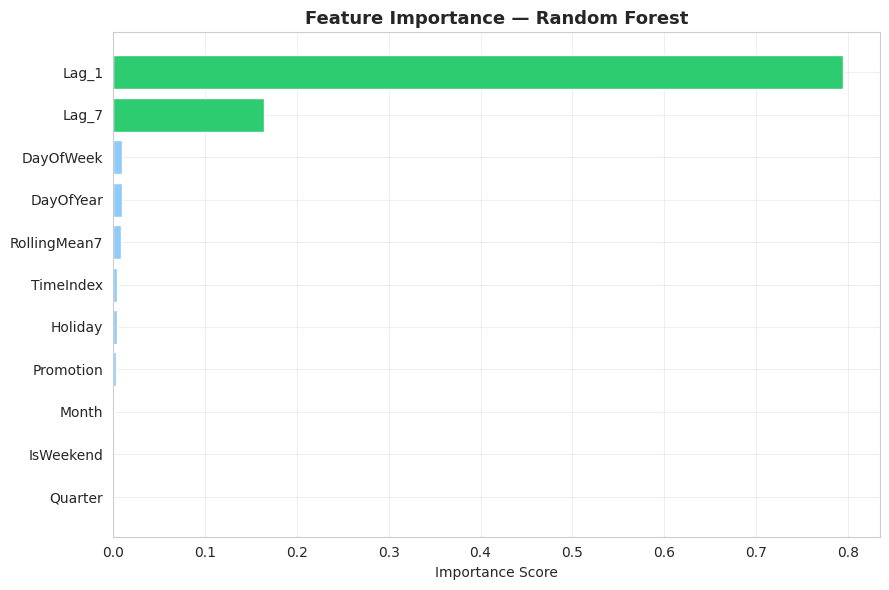

In [ ]:
imp_df = pd.DataFrame({'Feature': FEATURES, 'Importance': rf_model.feature_importances_}).sort_values('Importance')
colors = ['#2ecc71' if v > 0.1 else '#90caf9' for v in imp_df['Importance']]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df['Feature'], imp_df['Importance'], color=colors, edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.show()

---
##  Step 16: Export Results to CSV

In [2]:
out = future_df[['Date','Total_Units','IsWeekend','Holiday']].copy()
out.columns = ['Date','Predicted_Units_Sold','Is_Weekend','Is_Holiday']
out['Date'] = out['Date'].dt.strftime('%Y-%m-%d')
out['Predicted_Units_Sold'] = out['Predicted_Units_Sold'].round(0).astype(int)
out.to_csv('sales_forecast_30days.csv', index=False)
print(" Forecast exported to 'sales_forecast_30days.csv'")

results.to_csv('model_comparison.csv', index=False)
print(" Model comparison exported to 'model_comparison.csv'")

out.head(10)

NameError: name 'future_df' is not defined

---
##  Conclusion

This project built an end-to-end **Sales Forecasting System** using Python. Here is what was covered:

| Step | Task | Status |
|------|------|--------|
| 1 | Library setup |  |
| 2 | Synthetic dataset — 3 stores, 4 products, 3 years |  |
| 3 | Data preprocessing & feature engineering |  |
| 4 | Exploratory Data Analysis |  |
| 5 | Time series decomposition | |
| 6 | Stationarity testing (ADF) |  |
| 7 | Moving Average, Linear Regression, SARIMA, Random Forest |  |
| 8 | Model evaluation (MAE, MSE, RMSE) |  |
| 9 | 30-day future forecast with confidence band |  |
| 10 | Feature importance analysis |  |
| 11 | Results exported to CSV |  |

### Key Takeaways
- **Random Forest** outperformed all other models by capturing nonlinear relationships and lag patterns effectively.
- **SARIMA** handled seasonal structure well but needed careful parameter selection.
- Lag features (Lag_1, Lag_7, RollingMean7) were among the top predictors.
- Promotions and holidays showed a clear positive impact on sales volumes.

### Possible Next Steps
- Connect to a live database or sales API for real-time forecasting
- Implement LSTM for deep sequence modelling
- Add multi-step weekly and monthly forecast rollups
- Integrate with ERP or inventory management systems

---
*Sales Forecasting System | Python · Scikit-learn · Statsmodels · Matplotlib*